# AQUASPECT Proof of Concept
**Arab Youth Space Hackathon 813 | Theme 6: Water Quality & Inland/Coastal Water Intelligence**

This notebook demonstrates a reproducible pipeline for analyzing hyperspectral imagery (Planet Tanager) and establishing a multi-temporal baseline (Sentinel-2 L2A). 

> **Note on Validation:** Given the lack of open, concurrent in-situ samples for the analyzed locations and dates, outputs are presented as dimensionless statistical proxies rather than calibrated physical units (e.g., exact NTU). Anomalies are flagged based on statistical deviations from a historical baseline.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display, HTML
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path("c:/Users/wasfy/Downloads/AQUASPECT")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from aquaspect import preprocessing, indices, detection, visualization

DATA_DIR = PROJECT_ROOT / "data" / "sample_input"
RESULTS_MAPS = PROJECT_ROOT / "results" / "maps"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"


---
## El Gouna Hyperspectral Analysis (Planet Tanager)
**Scene:** `20250926_092059_95_4001`


In [ ]:
TANAGER_FILE = DATA_DIR / "20250926_092059_95_4001_ortho_sr_hdf5.h5"

valid_mask, qa_stats = preprocessing.build_qa_mask(str(TANAGER_FILE))
print("Scene QA Statistics:")
for k, v in qa_stats.items():
    print(f"  {k}: {v}")         


Scene QA Statistics:
  total_pixels: 687564
  valid_pixels: 448045
  invalid_pixels: 239519
  valid_pct: 65.16
  nodata_pct: 28.88
  cloud_pct: 5.96
  cirrus_pct: 0.0


HDF5 SR Array: (426, 852, 807) | Range: 376.4 - 2499.0 nm
  Target 443 nm -> Actual 441.1 nm
  Target 560 nm -> Actual 560.8 nm
  Target 665 nm -> Actual 665.9 nm
  Target 708 nm -> Actual 705.9 nm
  Target 800 nm -> Actual 801.1 nm
  Target 860 nm -> Actual 861.3 nm



Estimated Water Area: 212.37 km²


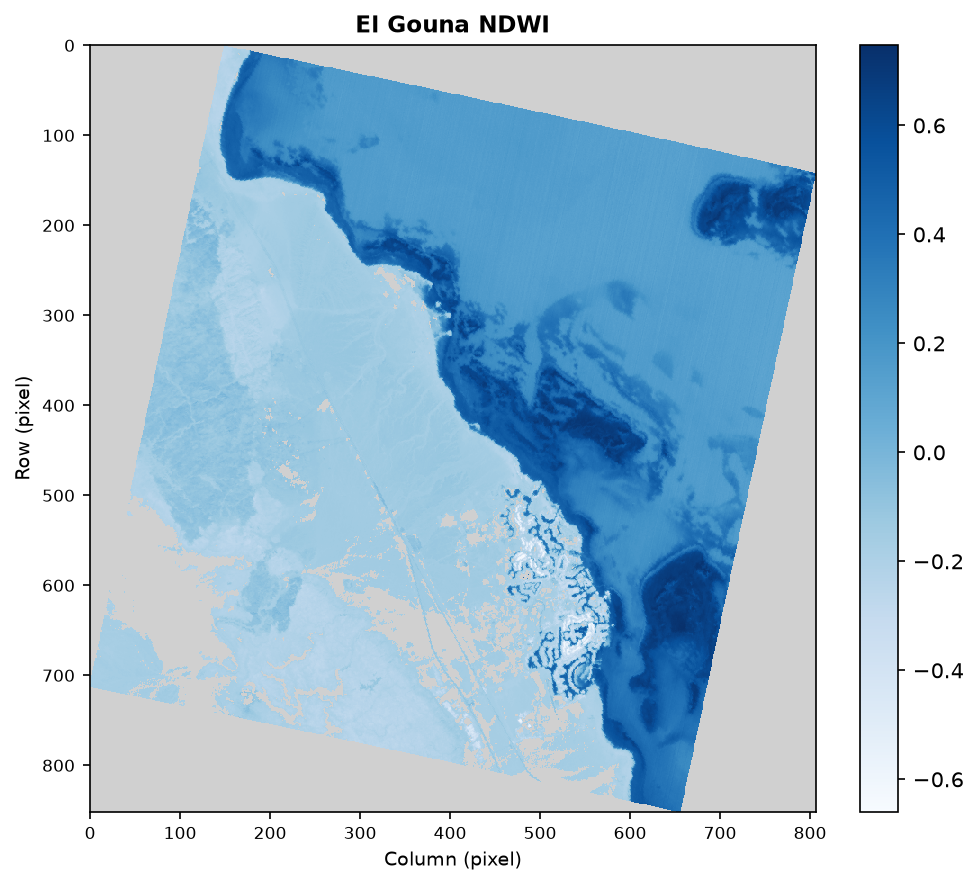

In [ ]:
with h5py.File(TANAGER_FILE, "r") as f:
    sr = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"]
    wavelengths = sr.attrs["wavelengths"][:]
    print(f"HDF5 SR Array: {sr.shape} | Range: {wavelengths[0]:.1f} - {wavelengths[-1]:.1f} nm")
    
    target_nms = [443, 560, 665, 708, 800, 860]
    band_indices = {t: np.argmin(np.abs(wavelengths - t)) for t in target_nms}
    for t, idx in band_indices.items():
        print(f"  Target {t} nm -> Actual {wavelengths[idx]:.1f} nm")
        
    def load_b(nm):
        arr = sr[band_indices[nm], :, :].astype(np.float32) * 1e-4
        arr[~valid_mask] = np.nan
        arr[(arr < 0) | (arr > 1)] = np.nan
        return arr
        
    b_green, b_red, b_rededge, b_nir2 = load_b(560), load_b(665), load_b(708), load_b(860)

ndwi_arr = indices.ndwi(b_green, b_nir2)
water_mask_raw = indices.water_mask(ndwi_arr, threshold=0.0)
water_mask, water_stats = detection.apply_water_mask(water_mask_raw & valid_mask, min_pixels=100, pixel_area_m2=900)

print(f"\nEstimated Water Area: {water_stats['estimated_area_km2']:.2f} km²")
display(Image(filename=str(RESULTS_MAPS / "elgouna_water_mask.png"), width=700))


In [ ]:
# Spatial Proxies
ndci_arr = indices.ndci(b_rededge, b_red)
turb_arr = indices.turbidity_proxy(b_red, b_green)

# Display side-by-side
html = f'''
<div style="display: flex; flex-direction: row; justify-content: space-between;">
  <img src="{RESULTS_MAPS / 'elgouna_chlorophyll_screening.png'}" style="width: 49%;"/>
  <img src="{RESULTS_MAPS / 'elgouna_turbidity_proxy.png'}" style="width: 49%;"/>
</div>
'''
display(HTML(html))


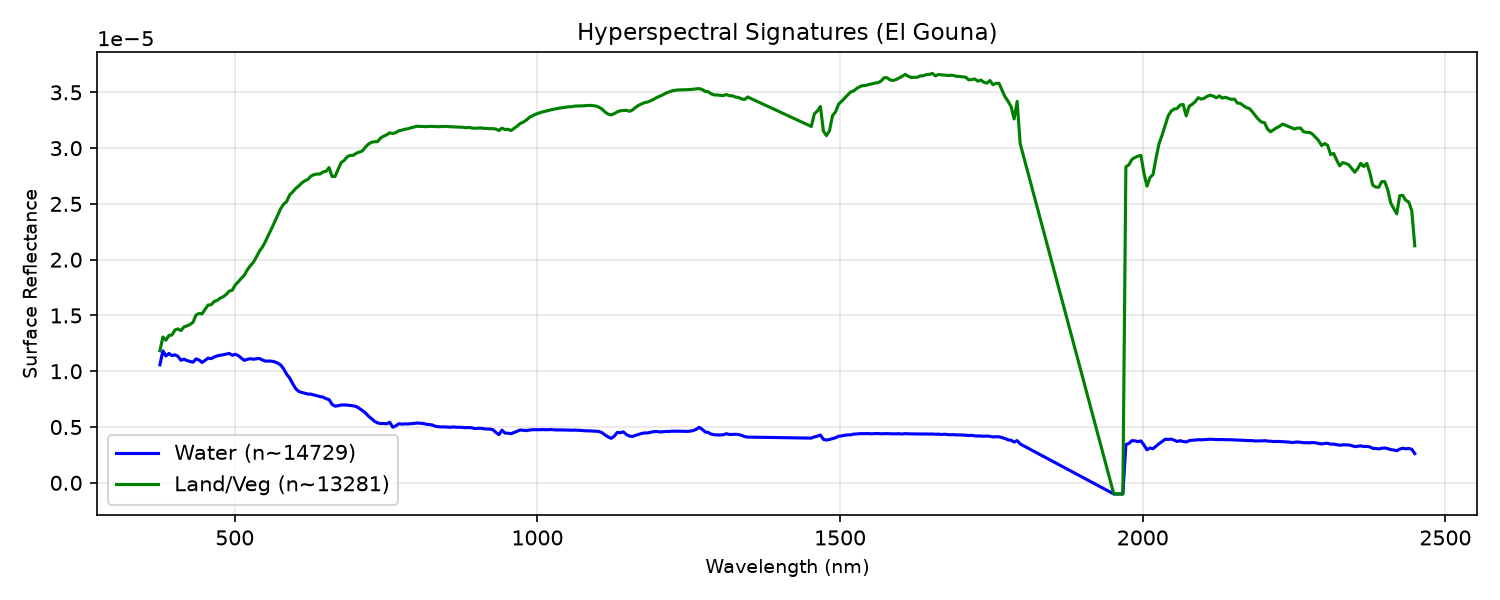

In [ ]:
# Hyperspectral Signature Extraction (426 bands)
display(Image(filename=str(RESULTS_FIGURES / "elgouna_hyperspectral_signature.png")))


---
## Lake Manzala Temporal Baseline (Sentinel-2 L2A)
Analysis across 8 distinct scenes spanning 12 months (June 2024 – May 2025).


,date,item_id,tile,cloud_pct,water_pixels,water_area_km2,mean_ndwi,mean_turbidity,std_turbidity,mean_ndci
0,2024-06-06,S2A_MSIL2A_20240606T082611_R021_T36RUV_2024060...,T36RUV,0.000000,41889,418.89,0.14243,-0.07308,0.02258,-0.07009
1,2024-07-21,S2B_MSIL2A_20240721T082609_R021_T36RTV_2024072...,T36RTV,0.000000,19329,193.29,0.19200,-0.08403,0.03286,-0.10989
2,2024-08-20,S2B_MSIL2A_20240820T082559_R021_T36RTV_2024082...,T36RTV,0.000000,20143,201.43,0.16559,-0.10158,0.03253,-0.06524
3,2024-09-27,S2A_MSIL2A_20240927T083731_R064_T36RUV_2024092...,T36RUV,0.000000,28252,282.52,0.15115,-0.10158,0.02791,-0.05055
4,2024-10-04,S2A_MSIL2A_20241004T082811_R021_T36RVV_2024100...,T36RVV,5.940000,410013,4100.13,0.16083,-0.10437,0.01991,-0.05745
5,2024-12-28,S2B_MSIL2A_20241228T083259_R021_T36RVV_2024122...,20241228T093822,0.053533,466347,4663.47,0.16411,-0.09021,0.02347,-0.07498
6,2025-01-30,S2B_MSIL2A_20250130T084119_R064_T36RUV_2025013...,20250130T124050,0.027967,48003,480.03,0.16823,-0.08750,0.02041,-0.08204
7,2025-04-27,S2A_MSIL2A_20250427T084501_R064_T36RTV_2025042...,T36RTV,3.970000,41281,412.81,0.14999,-0.07901,0.03411,-0.07193


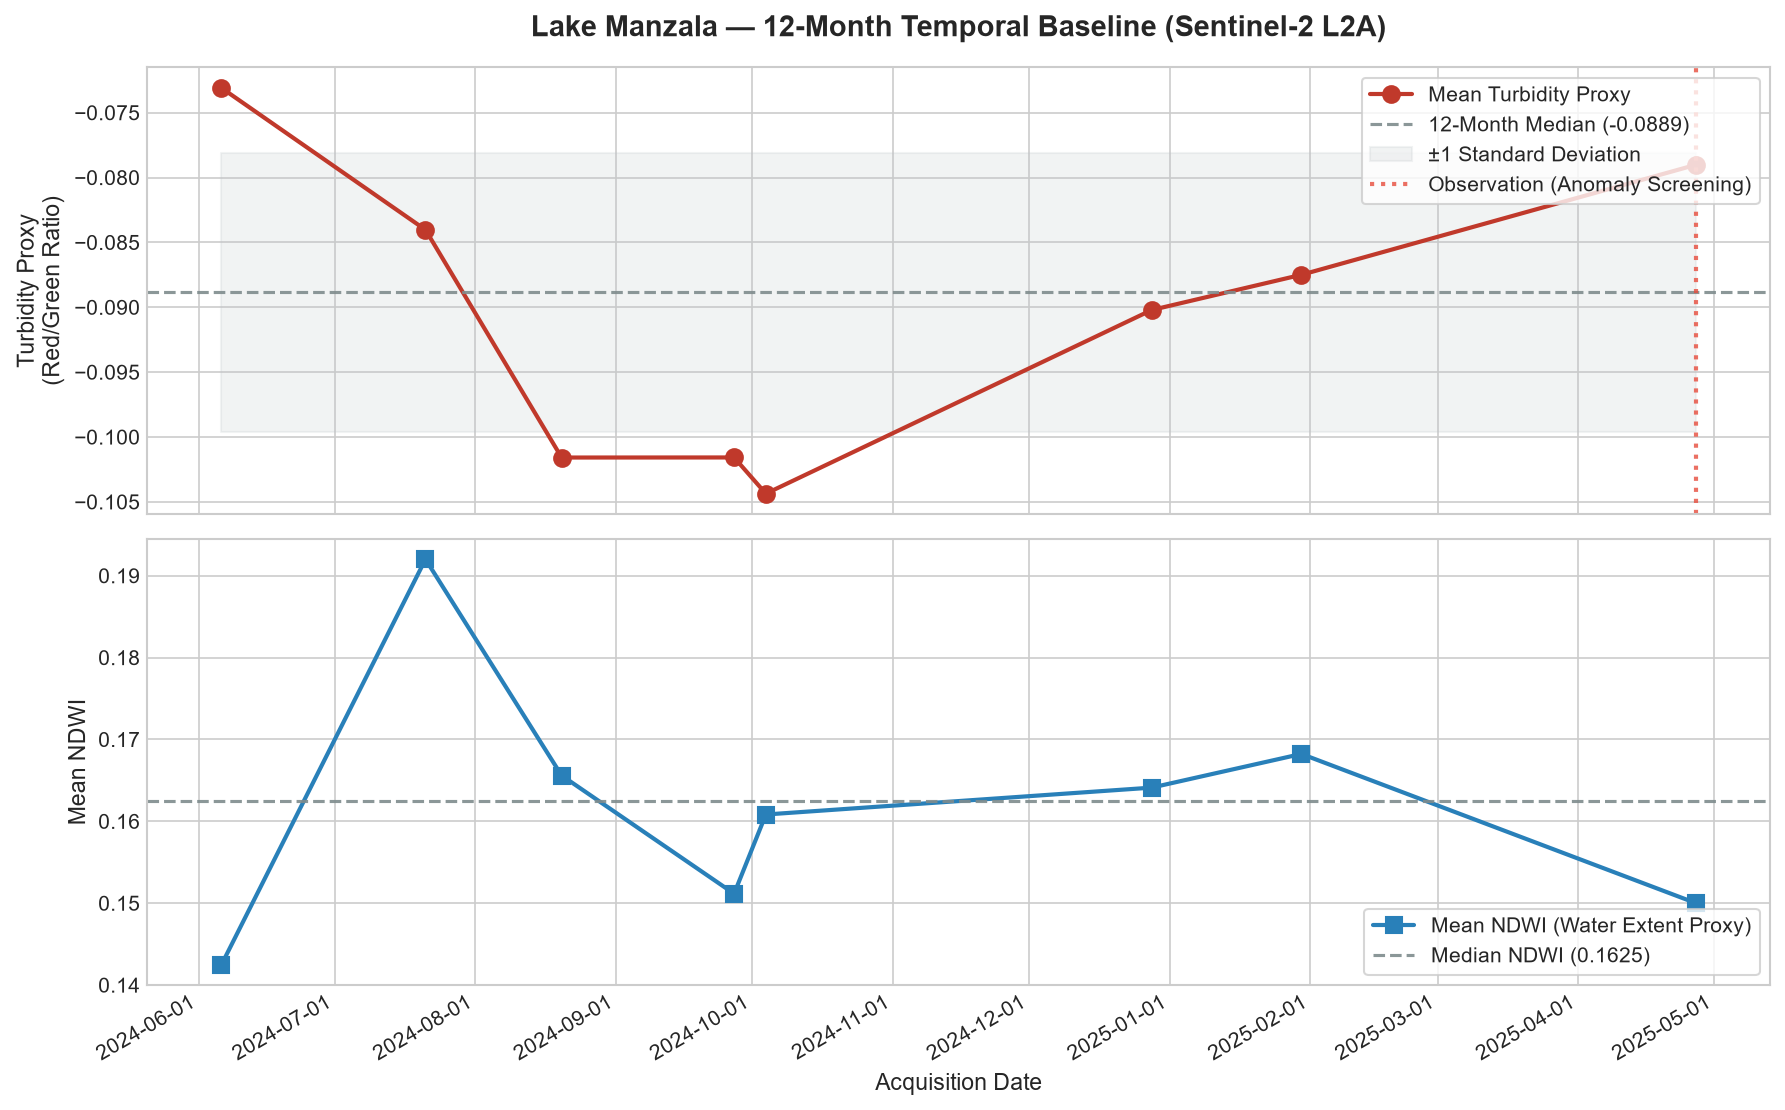

In [6]:
s2_metrics = pd.read_csv(PROJECT_ROOT / "results" / "tables" / "manzala_temporal_metrics.csv")
display(s2_metrics)

display(Image(filename=str(RESULTS_FIGURES / "manzala_temporal_baseline.png")))


In [7]:
anomaly_summary = pd.read_csv(PROJECT_ROOT / "results" / "tables" / "manzala_anomaly_summary.csv")
total_water = s2_metrics.iloc[-1]['water_pixels']
extreme_px = anomaly_summary.iloc[0]['anomaly_extreme_px']

print("Anomaly Detection (Z-Score Baseline):")
display(anomaly_summary)

print(f"\nFor the latest observation ({anomaly_summary.iloc[0]['reference_date']}):")
print(f"Detected {extreme_px:,} pixels ({extreme_px/total_water:.1%}) with Z-score ≥ 3.0.")
print("This indicates a statistically extreme deviation from the 12-month median, warranting further investigation.")


Anomaly Detection (Z-Score Baseline):


,reference_date,anomaly_normal_px,anomaly_elevated_px,anomaly_high_px,anomaly_extreme_px,z_threshold_elevated,z_threshold_high,z_threshold_extreme
0,2025-04-27,22989,2343,2676,13273,1.0,2.0,3.0



For the latest observation (2025-04-27):
Detected 13,273 pixels (32.2%) with Z-score ≥ 3.0.
This indicates a statistically extreme deviation from the 12-month median, warranting further investigation.
